24BAD050-JOHIYA SRI S


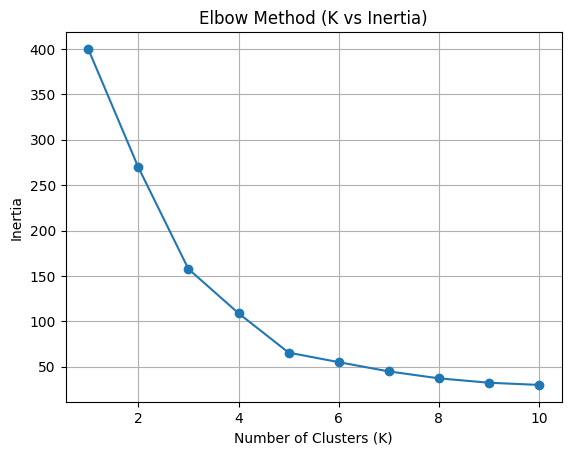


Inertia: 65.5684081557168
Silhouette Score: 0.5546571631111091


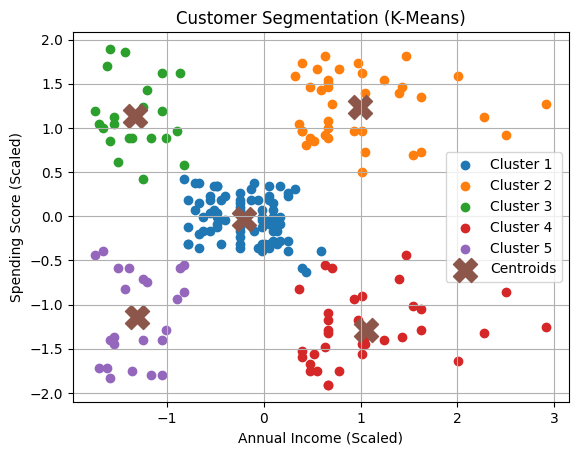


Cluster-wise Mean Values:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
1                 55.296296               49.518519
2                 86.538462               82.128205
3                 25.727273               79.363636
4                 88.200000               17.114286
5                 26.304348               20.913043

Sample Data with Cluster Labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        5  
1        3  
2        5  
3        3  
4        5  


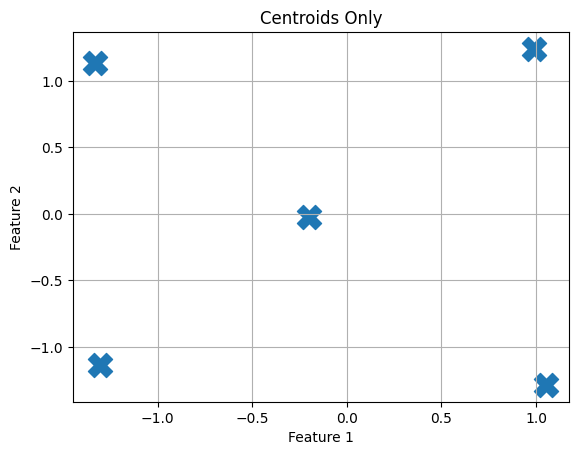

In [2]:
print("24BAD050-JOHIYA SRI S")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

data = pd.read_csv(r"C:\Users\Sibiya Shri\Downloads\Mall_Customers.csv")

if data.isnull().sum().any():
    data = data.dropna()

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method (K vs Inertia)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid()
plt.show()

optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters + 1

inertia_value = kmeans.inertia_
sil_score = silhouette_score(X_scaled, kmeans.labels_)

print(f"\nInertia: {inertia_value}")
print(f"Silhouette Score: {sil_score}")

plt.figure()

for i in range(1, optimal_k + 1):
    plt.scatter(
        X_scaled[data['Cluster'] == i, 0],
        X_scaled[data['Cluster'] == i, 1],
        label=f'Cluster {i}'
    )

centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation (K-Means)")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.grid()
plt.show()

print("\nCluster-wise Mean Values:")
print(data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

print("\nSample Data with Cluster Labels:")
print(data.head())

plt.figure()
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=300
)
plt.title("Centroids Only")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.show()

24BAD050-JOHIYA SRI


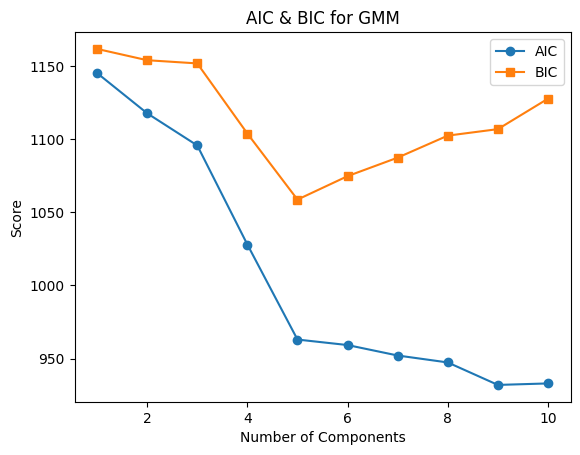


Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


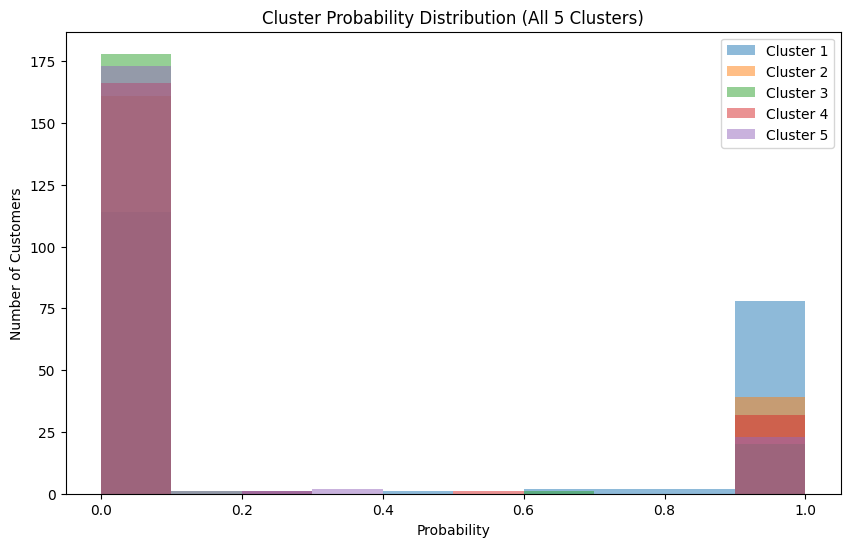

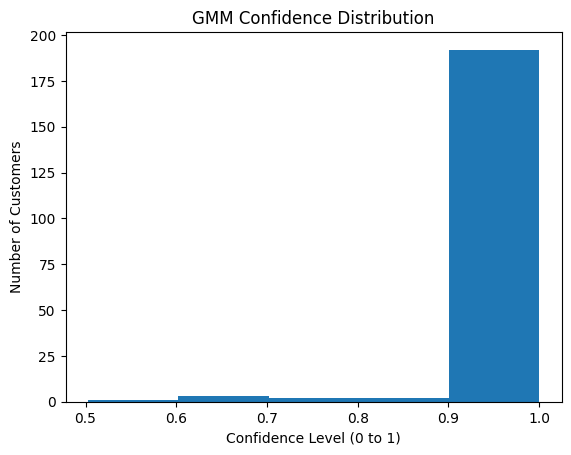

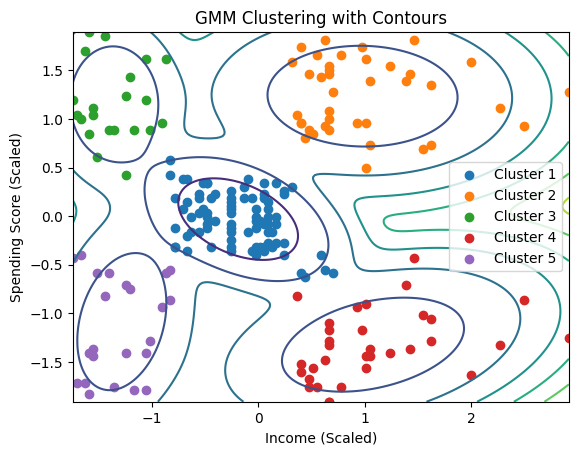

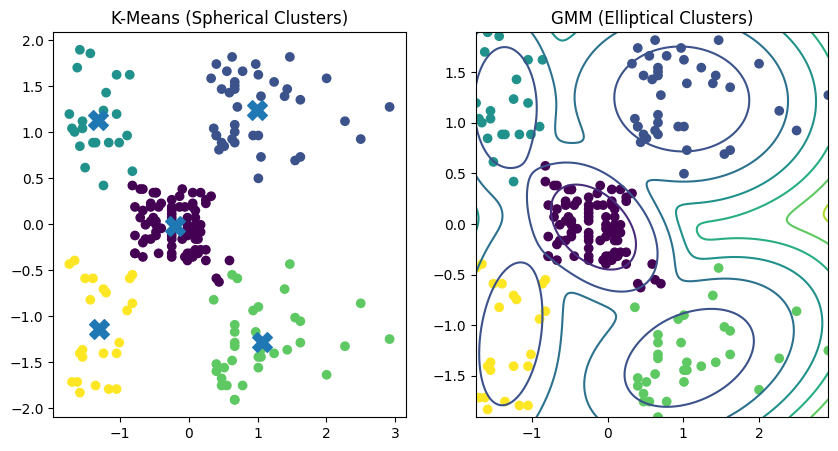


Cluster Means (GMM):
             Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                            
1                     55.642857               49.369048
2                     86.538462               82.128205
3                     25.095238               80.047619
4                     88.818182               16.000000
5                     26.304348               20.913043

Sample Data:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   GMM_Cluster  
0            5  
1            3  
2            5  
3            3  
4            5  


In [3]:
print("24BAD050-JOHIYA SRI")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

data = pd.read_csv(r"C:\Users\Sibiya Shri\Downloads\Mall_Customers.csv")

if data.isnull().sum().any():
    data = data.dropna()

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

aic = []
bic = []
K_range = range(1, 11)

for k in K_range:
    gmm_temp = GaussianMixture(n_components=k, random_state=42)
    gmm_temp.fit(X_scaled)
    aic.append(gmm_temp.aic(X_scaled))
    bic.append(gmm_temp.bic(X_scaled))

plt.figure()
plt.plot(K_range, aic, marker='o', label='AIC')
plt.plot(K_range, bic, marker='s', label='BIC')
plt.title("AIC & BIC for GMM")
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.legend()
plt.show()

optimal_k = 5

gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm.fit(X_scaled)

probabilities = gmm.predict_proba(X_scaled)

clusters = np.argmax(probabilities, axis=1)
data['GMM_Cluster'] = clusters + 1

log_likelihood = gmm.score(X_scaled)
sil_score = silhouette_score(X_scaled, clusters)

print(f"\nLog-Likelihood: {log_likelihood}")
print(f"AIC: {gmm.aic(X_scaled)}")
print(f"BIC: {gmm.bic(X_scaled)}")
print(f"Silhouette Score: {sil_score}")

plt.figure(figsize=(10,6))
for i in range(optimal_k):
    plt.hist(probabilities[:, i], bins=10, alpha=0.5, label=f'Cluster {i+1}')
plt.title("Cluster Probability Distribution (All 5 Clusters)")
plt.xlabel("Probability")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

plt.figure()
max_probs = probabilities.max(axis=1)
plt.hist(max_probs, bins=5)
plt.title("GMM Confidence Distribution")
plt.xlabel("Confidence Level (0 to 1)")
plt.ylabel("Number of Customers")
plt.show()

plt.figure()
for i in range(1, optimal_k + 1):
    plt.scatter(
        X_scaled[data['GMM_Cluster'] == i, 0],
        X_scaled[data['GMM_Cluster'] == i, 1],
        label=f'Cluster {i}'
    )

x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 200)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 200)
X_grid, Y_grid = np.meshgrid(x, y)
grid = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.contour(X_grid, Y_grid, Z)
plt.title("GMM Clustering with Contours")
plt.xlabel("Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.show()

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_clusters)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')
plt.title("K-Means (Spherical Clusters)")

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)
plt.contour(X_grid, Y_grid, Z)

plt.title("GMM (Elliptical Clusters)")
plt.show()

print("\nCluster Means (GMM):")
print(data.groupby('GMM_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

print("\nSample Data:")
print(data.head())